In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('insurance_claim_updated.csv')

In [4]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital.gains', 'capital.loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported'],
      dtype='object')

**Data Cleaning**

In [5]:
df.shape

(10211, 39)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10211 entries, 0 to 10210
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           10211 non-null  int64  
 1   age                          10211 non-null  int64  
 2   policy_number                10211 non-null  int64  
 3   policy_bind_date             10211 non-null  object 
 4   policy_state                 10211 non-null  object 
 5   policy_csl                   10211 non-null  object 
 6   policy_deductable            10211 non-null  int64  
 7   policy_annual_premium        10211 non-null  float64
 8   umbrella_limit               10211 non-null  float64
 9   insured_zip                  10211 non-null  int64  
 10  insured_sex                  10211 non-null  object 
 11  insured_education_level      10211 non-null  object 
 12  insured_occupation           10211 non-null  object 
 13  insured_hobbies 

In [7]:
#change date from object to datetime
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'],errors='coerce').dt.date
##df['incident_date'] = pd.to_datetime(df['incident_date'],errors='coerce',format='Mixed', dayfirst=True)

<ipython-input-7-bbef26fb8e5a>:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'],errors='coerce').dt.date


In [8]:
print(df[['policy_bind_date', 'incident_date']].isna().sum())


policy_bind_date    0
incident_date       0
dtype: int64


In [9]:
df.describe()#descriptive

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital.gains,capital.loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year
count,10211.000000,10211.000000,1.021100e+04,10211.000000,10211.000000,1.021100e+04,10211.000000,10211.000000,10211.000000,10211.000000,10211.000000,10211.000000,10211.000000,10211.000000,10211.000000,10211.000000,10211.000000,10211.000000
mean,213.467927,39.050142,5.474680e+05,1159.044168,1257.794204,1.727157e+06,503057.770248,16459.434531,17150.482029,11.229850,2.010087,1.139262,1.652434,56608.934482,7912.681422,8028.269513,40822.630497,2004.358927
std,133.639732,11.508964,3.034069e+05,621.773731,300.874661,2.407828e+06,88766.415575,24596.437735,25528.629014,6.411803,1.101773,0.896285,1.195957,27647.190092,5456.281497,5514.767560,19666.958809,6.442418
min,0.000000,2.000000,4.410000e+02,500.000000,179.790000,0.000000e+00,203707.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,100.000000,0.000000,0.000000,10.000000,1981.000000
25%,106.000000,31.000000,3.095050e+05,500.000000,1058.790000,0.000000e+00,436706.000000,0.000000,0.000000,6.000000,1.000000,0.000000,1.000000,37930.000000,3615.000000,3730.000000,27700.000000,2000.000000
50%,202.000000,38.000000,5.364750e+05,1000.000000,1255.210000,1.000000e+06,485493.000000,155.000000,0.000000,12.000000,2.000000,1.000000,2.000000,58200.000000,7460.000000,7600.000000,42200.000000,2005.000000
75%,303.000000,47.000000,7.717955e+05,2000.000000,1454.130000,3.000000e+06,569575.500000,26191.000000,27564.000000,16.000000,3.000000,2.000000,3.000000,76000.000000,11800.000000,11770.000000,54700.000000,2009.000000
max,747.000000,79.000000,1.615353e+06,2000.000000,2390.510000,1.000000e+07,788825.000000,134607.000000,142321.000000,24.000000,6.000000,4.000000,6.000000,154740.000000,30000.000000,29700.000000,110800.000000,2015.000000


In [10]:
#check null/nan values
df.isna().sum().sort_values(ascending=False)

,0
authorities_contacted,707
witnesses,0
incident_state,0
incident_city,0
incident_location,0
incident_hour_of_the_day,0
number_of_vehicles_involved,0
property_damage,0
bodily_injuries,0
months_as_customer,0


In [11]:
print(df['authorities_contacted'].unique())

['Other' nan 'Police' 'Fire' 'Ambulance']


In [12]:
# handling nan value in authorities_contacted
df['authorities_contacted'].fillna("NO", inplace=True)

<ipython-input-12-561927bb1a8b>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['authorities_contacted'].fillna("NO", inplace=True)


In [13]:
#check unique values for all coulmns and inconsistent values
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())  # Shows all unique values
    print("-" * 40)

Column: months_as_customer
[  5 462 198 384 100 306 105 249  44 104 173 135 176  79 169  89  85   9
 150 134  11 319  10 423 330 371 401  16 273 275 217 136 232 357 345  12
  75 458  90 392 592 262 258 231 128 189 212 154 146  22 284 112 300 172
 247 124  97 343 317 651 333   1 551  61 463 288 560  70 441 113  27 338
 280 238 188 434 289 307 132 310 140  63 207 524 248 325 506 234 457 304
  68 634 265 267 385 424 364 359 303 139 478 279 148 425  74 283 285 410
  94 351  78 142 205  49 242 407 201  40 180 391 507 293  13 214 396 138
 147  98 430 145 448 340 261  66 237 175 486 192  62 143  58 159 178 226
 122 174 296 408 133 420 313 246 230 454 272  48 199 193 439  95 259 115
 274  69 118 220 255  87 320   3 584 213  15 257  19 368 491  38 194 504
 129 223 197 120 131 271 206 153 208 332 276 161  54  72 568 369 240  17
 538  60 202 361  84 294  53 183  50 167  33 200  39 209 312  34 414 316
  93 103 141 256 177 245 186 218  23 107 254 321 510 335 170 236  92  20
 365  41 402 191  91 227

In [14]:
# handling inconsistency// ? in collision_type,property_damage,police_report_available
df['collision_type'].replace("?", "Unknown", inplace=True)
df['property_damage'].replace("?", "Unknown", inplace=True)
df['police_report_available'].replace("?", "Unknown", inplace=True)

<ipython-input-14-b2bc1a48afd7>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['collision_type'].replace("?", "Unknown", inplace=True)
<ipython-input-14-b2bc1a48afd7>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [15]:
print(df['collision_type'].unique())
print(df['property_damage'].unique())
print(df['police_report_available'].unique())

['Front Collision' 'Rear Collision' 'Unknown' 'Side Collision']
['Unknown' 'NO' 'YES']
['YES' 'Unknown' 'NO']


In [16]:
#check duplicated rows
print(f"Duplicate Rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)  # Remove if needed

Duplicate Rows: 0


In [17]:
# Select numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

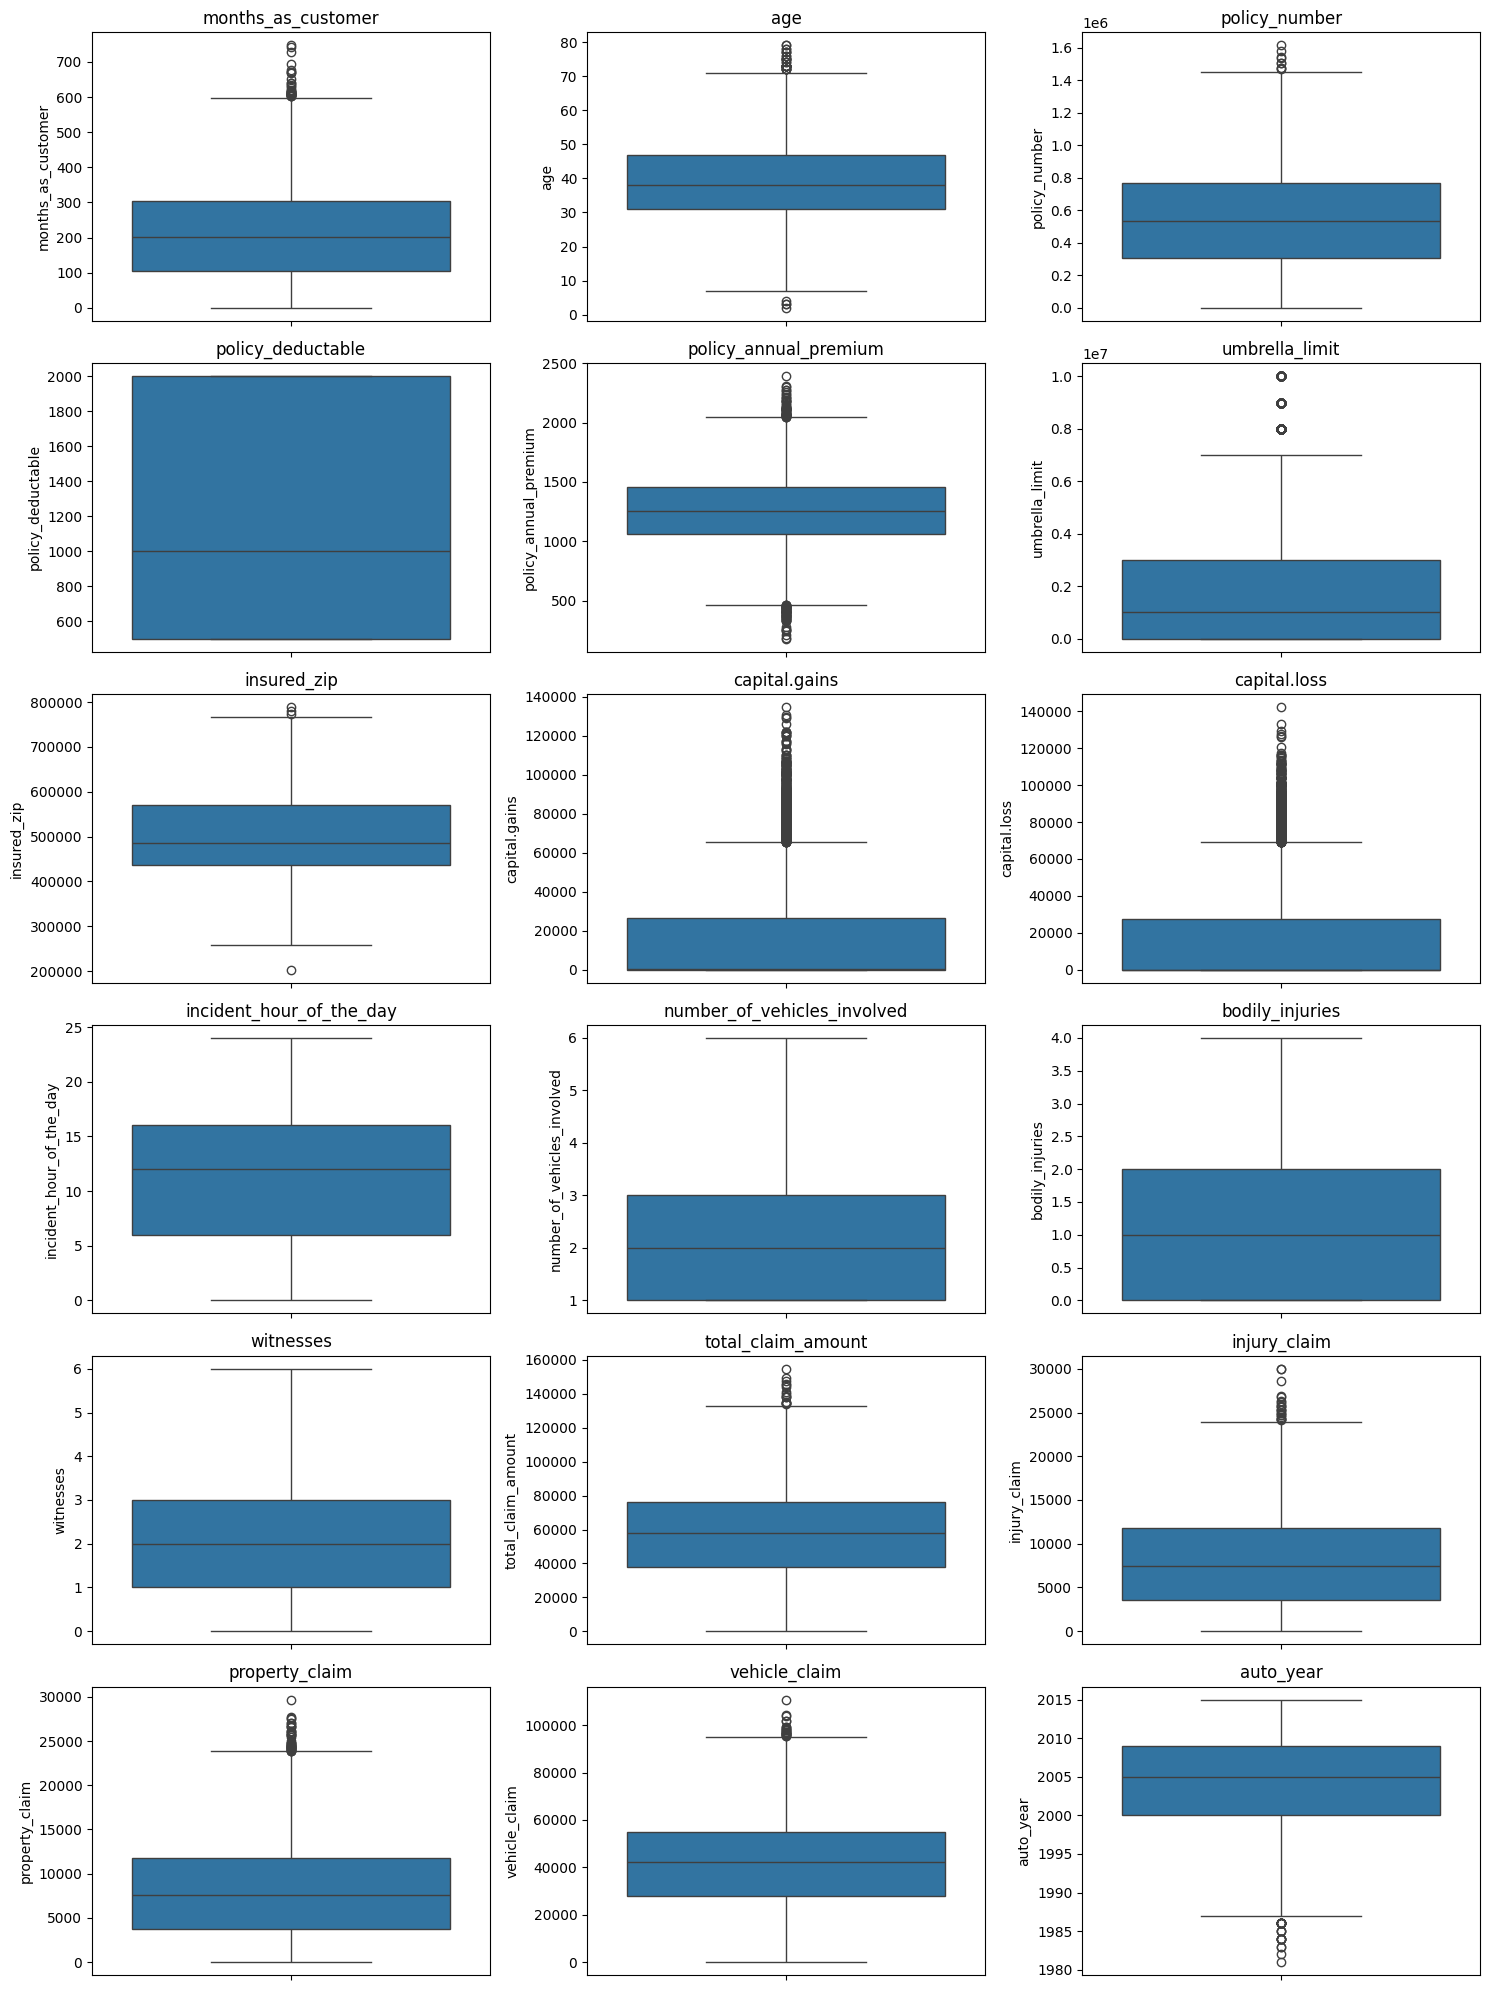

In [18]:
# Plot boxplots for numerical columns
plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(6, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.tight_layout()
plt.show()

In [19]:
# Function to cap outliers using IQR method
new_df=df.copy()
def cap_outliers(new_df, col):
    Q1 = new_df[col].quantile(0.25)
    Q3 = new_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    new_df[col] = new_df[col].clip(lower=lower_bound, upper=upper_bound)
    return new_df

# List of numerical columns with visible outliers
outlier_cols = ['policy_annual_premium', 'umbrella_limit', 'capital.gains', 'capital.loss',
                'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim']

# Apply outlier capping
for col in outlier_cols:
    new_df = cap_outliers(new_df, col)

In [20]:
new_df.dtypes

,0
months_as_customer,int64
age,int64
policy_number,int64
policy_bind_date,object
policy_state,object
policy_csl,object
policy_deductable,int64
policy_annual_premium,float64
umbrella_limit,float64
insured_zip,int64


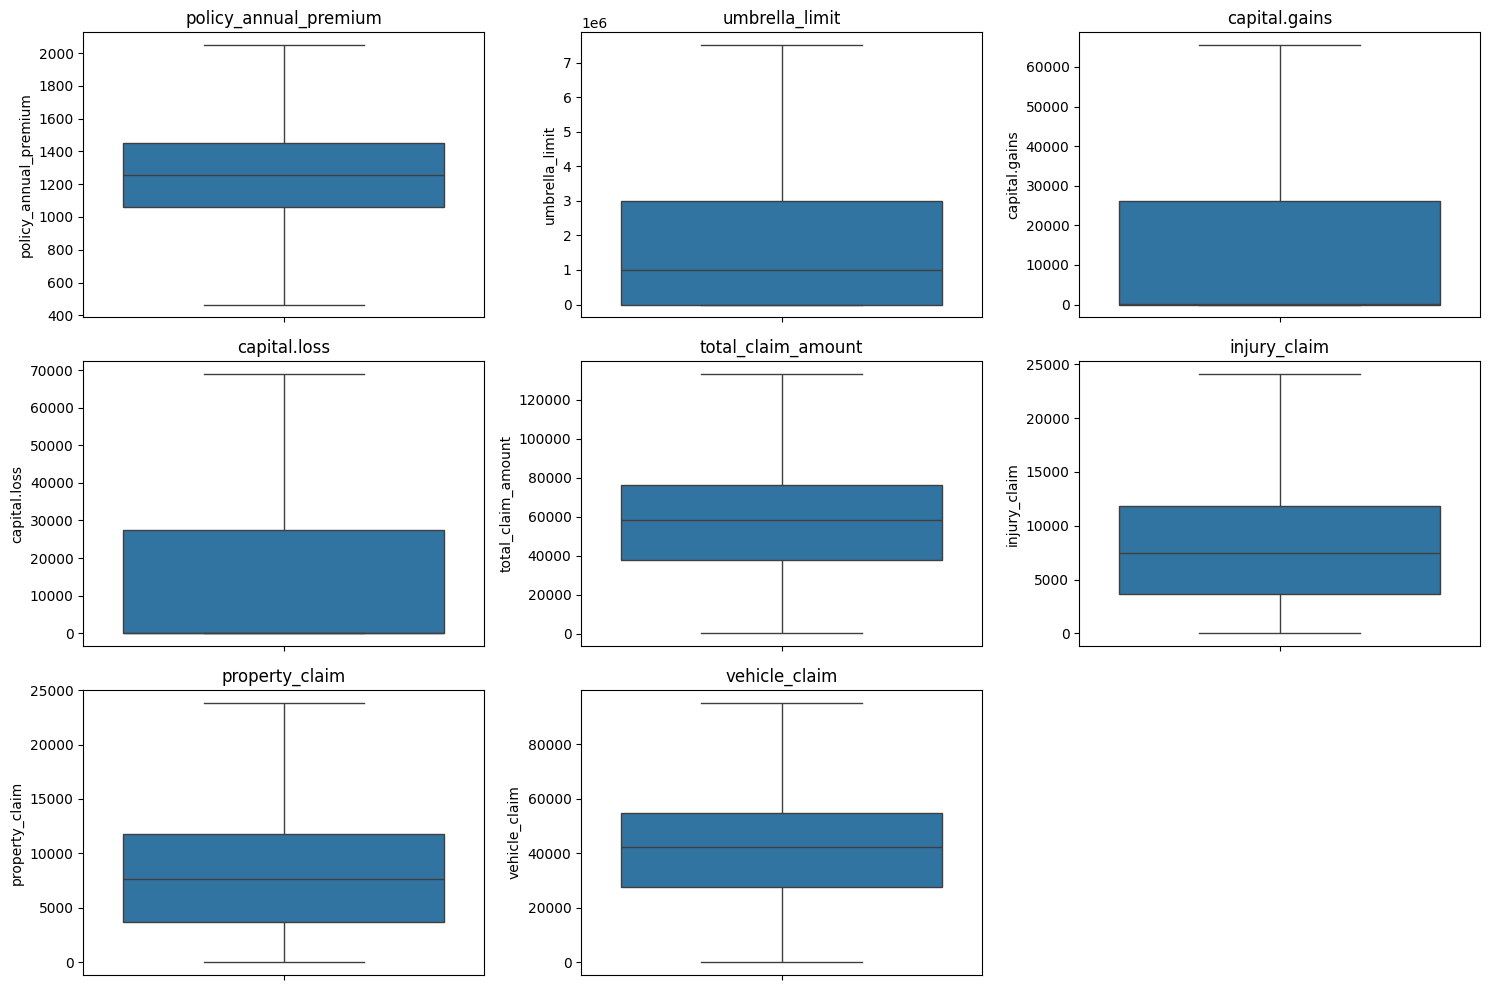

In [186]:
# Verify the changes with new boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=new_df[col])
    plt.title(col)
    plt.tight_layout()
plt.show()

**Numerical-Univariate analysis for each group ie customer and policy ,incident ,claim amounts**

In [187]:
num_cols =new_df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['months_as_customer', 'age', 'policy_number', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip',
       'capital.gains', 'capital.loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim',
       'auto_year'],
      dtype='object')


Policy & Customer-Related Numerical Variables


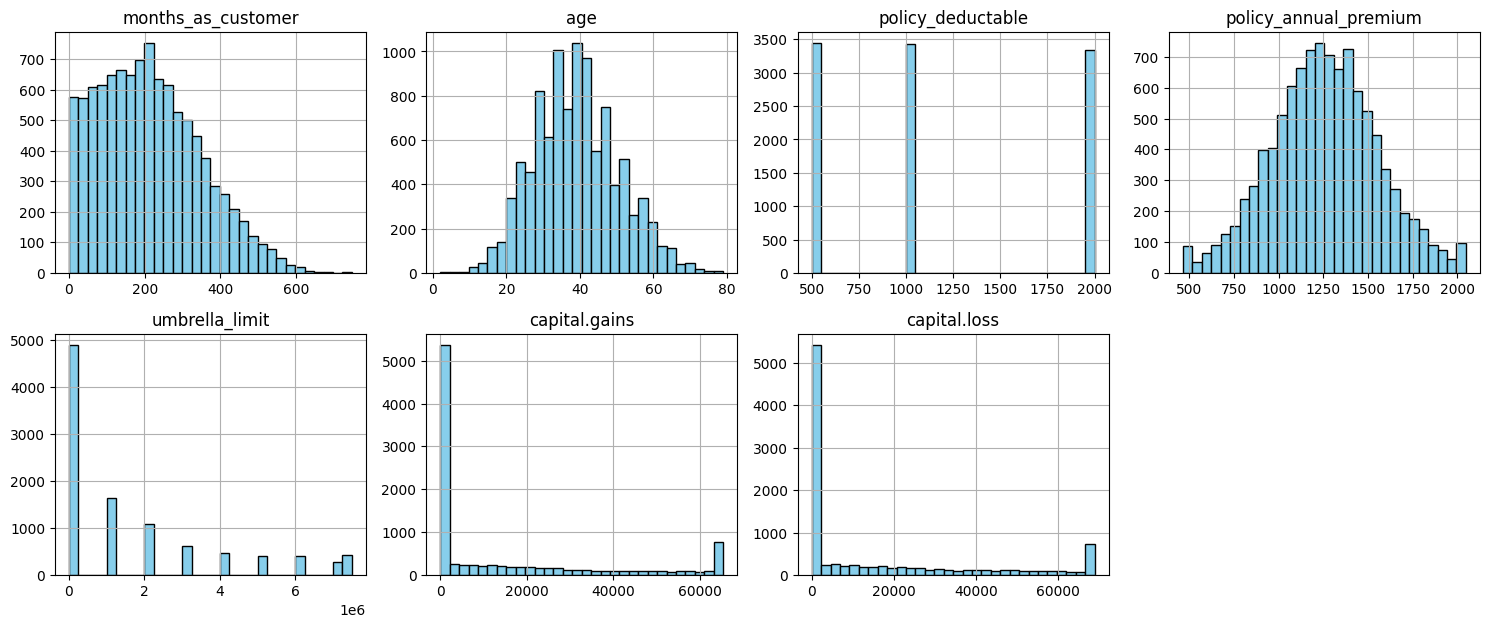

Incident-Related Numerical Variables


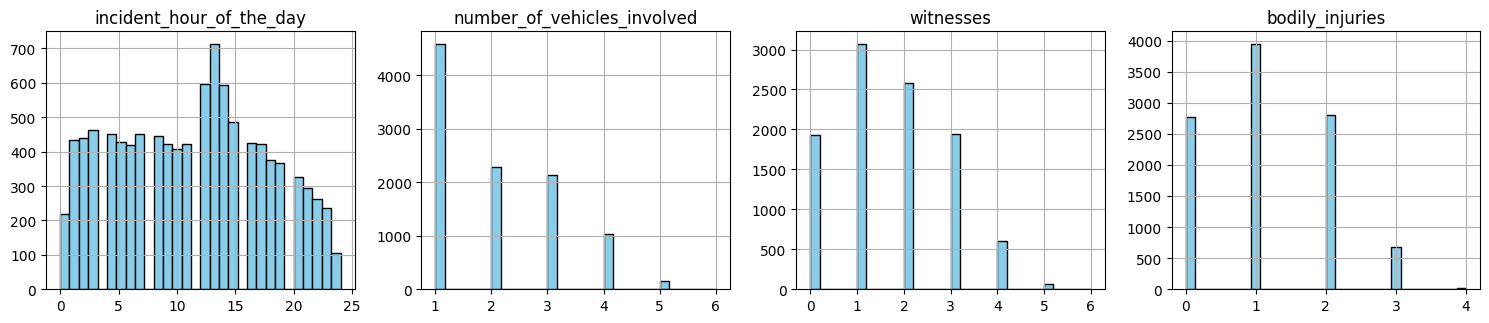

Claim Amounts


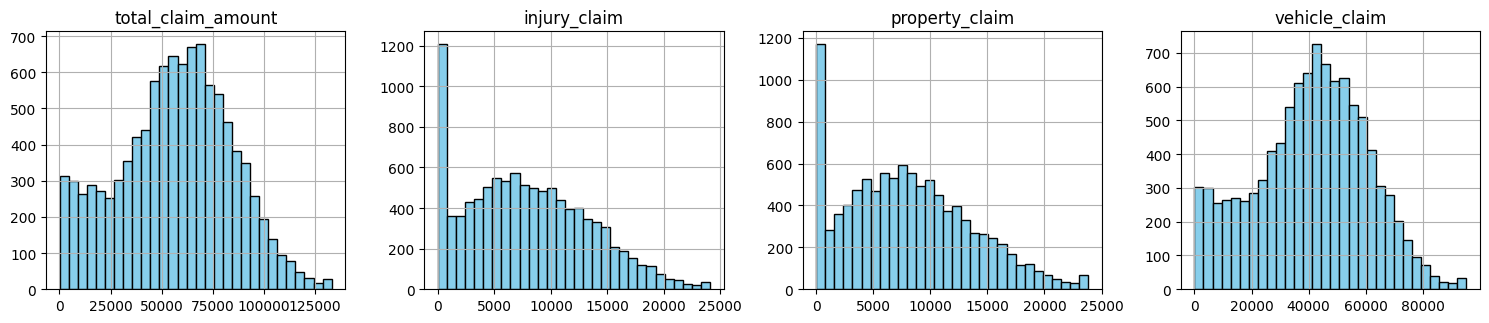

In [188]:

# Policy & Customer-Related Numerical Variables
print("Policy & Customer-Related Numerical Variables")
num_cols = ['months_as_customer','age', 'policy_deductable', 'policy_annual_premium','umbrella_limit',
            'capital.gains', 'capital.loss']

plt.figure(figsize=(15,12))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    new_df[col].hist(bins=30, color='skyblue', edgecolor='black')
    plt.title(col)
plt.tight_layout()
plt.show()
print("Incident-Related Numerical Variables")
num_cols = ['incident_hour_of_the_day', 'number_of_vehicles_involved', 'witnesses', 'bodily_injuries']

plt.figure(figsize=(15,12))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    new_df[col].hist(bins=30, color='skyblue', edgecolor='black')
    plt.title(col)
plt.tight_layout()
plt.show()

print("Claim Amounts")
num_cols = ['total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim']

plt.figure(figsize=(15,12))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    new_df[col].hist(bins=30, color='skyblue', edgecolor='black')
    plt.title(col)
plt.tight_layout()
plt.show()

**Categorical-Univariate analysis for each group ie customer and policy ,incident ,vehicle**

In [189]:
cat_cols =new_df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_city', 'incident_location',
       'property_damage', 'police_report_available', 'auto_make', 'auto_model',
       'fraud_reported'],
      dtype='object')


<ipython-input-190-e295bca01a7a>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="coolwarm")


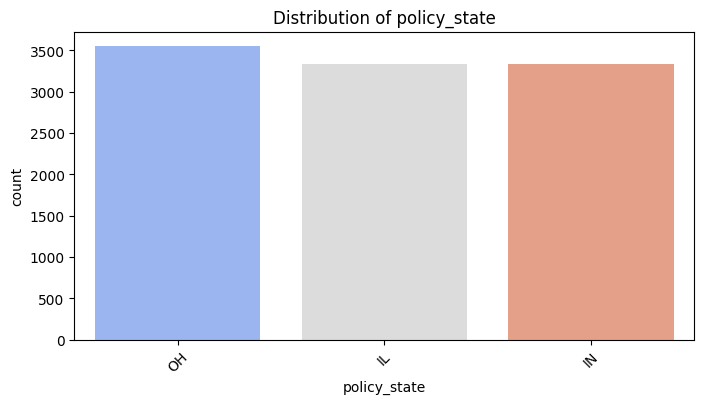

<ipython-input-190-e295bca01a7a>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="coolwarm")


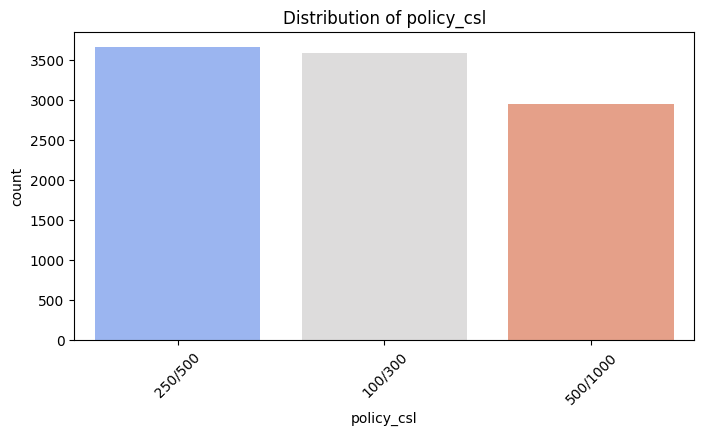

<ipython-input-190-e295bca01a7a>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="coolwarm")


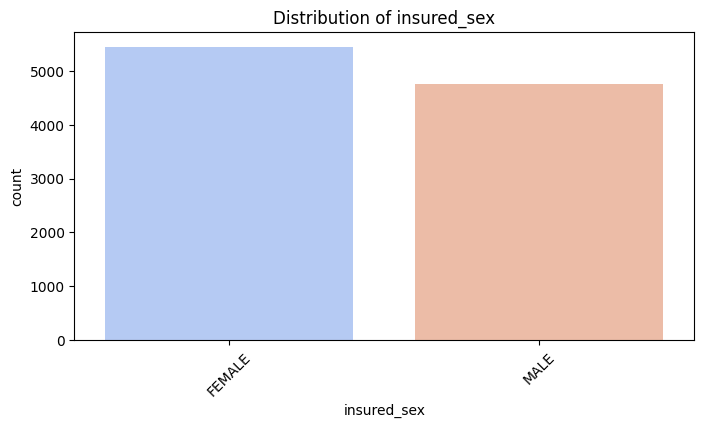

<ipython-input-190-e295bca01a7a>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="coolwarm")


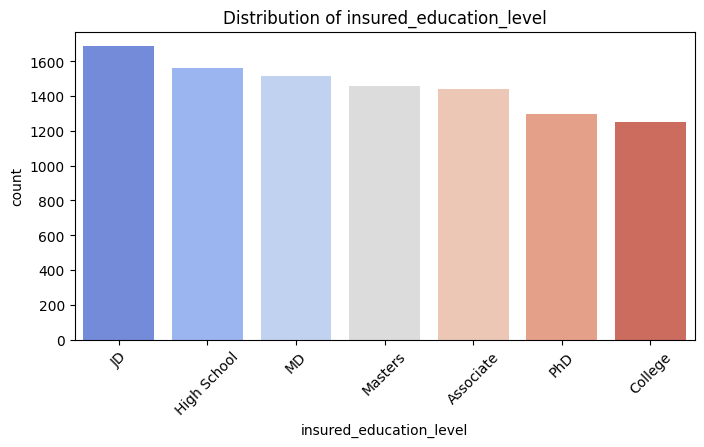

<ipython-input-190-e295bca01a7a>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="coolwarm")


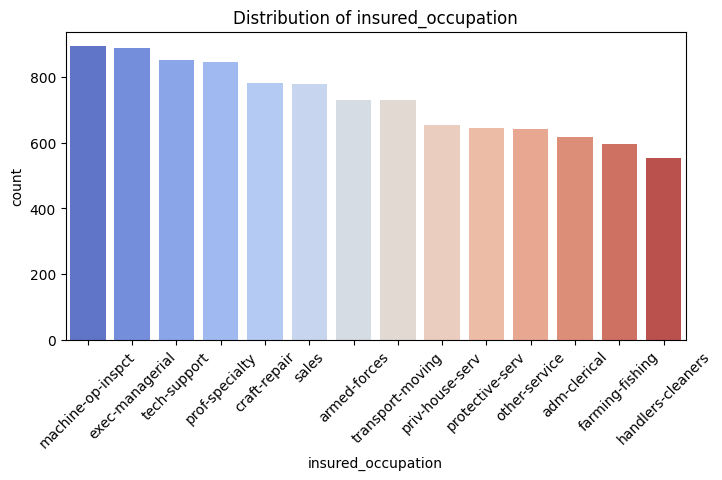

<ipython-input-190-e295bca01a7a>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="coolwarm")


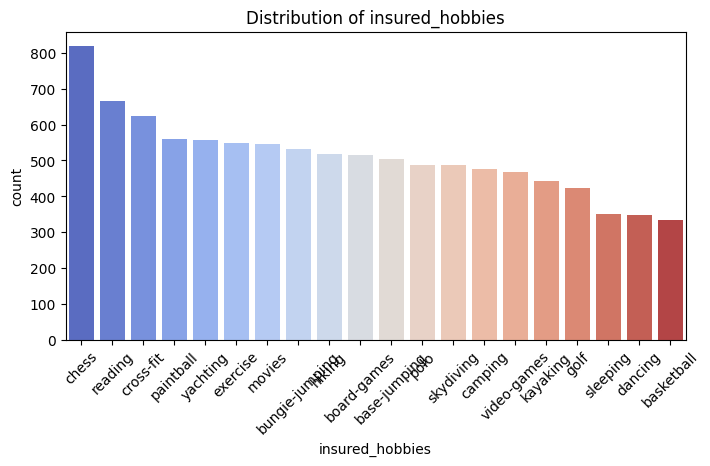

<ipython-input-190-e295bca01a7a>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="coolwarm")


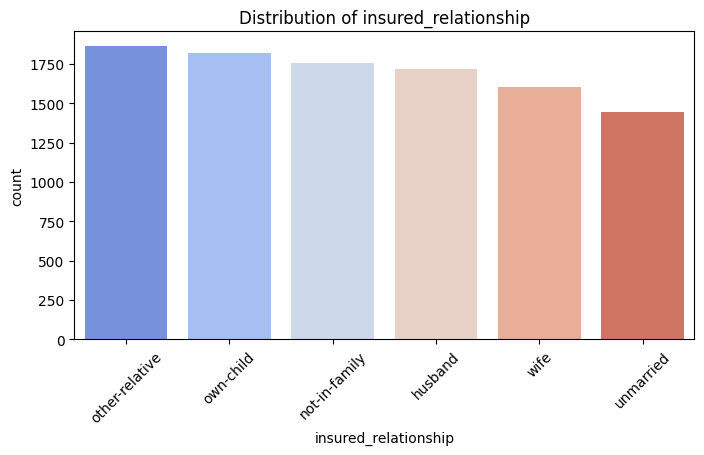

In [190]:
#Policy & Customer-Related Variables
#Value Counts for Each Category
policy_cols = ['policy_state', 'policy_csl', 'insured_sex',
               'insured_education_level', 'insured_occupation',
               'insured_hobbies', 'insured_relationship']

for col in policy_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="coolwarm")
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()



<ipython-input-191-ac7d0284b9eb>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="viridis")


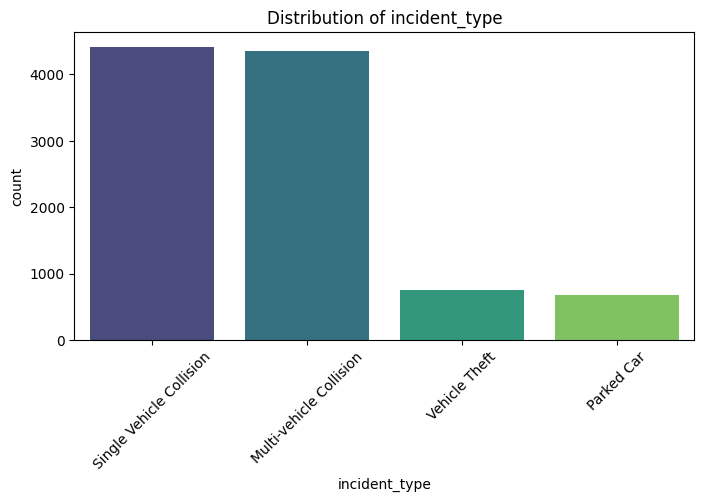

<ipython-input-191-ac7d0284b9eb>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="viridis")


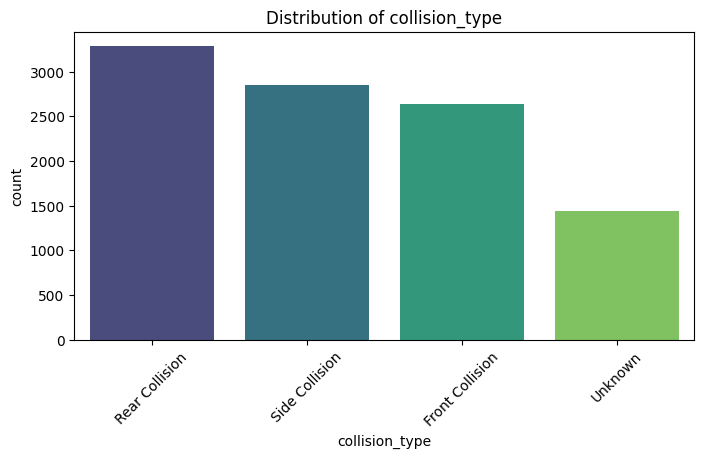

<ipython-input-191-ac7d0284b9eb>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="viridis")


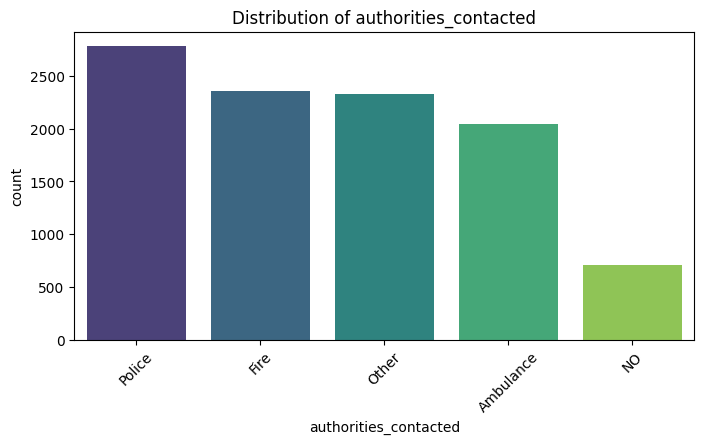

<ipython-input-191-ac7d0284b9eb>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="viridis")


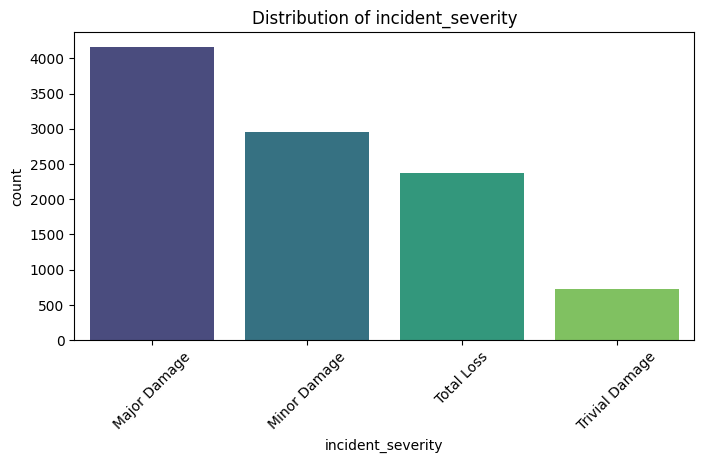

<ipython-input-191-ac7d0284b9eb>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="viridis")


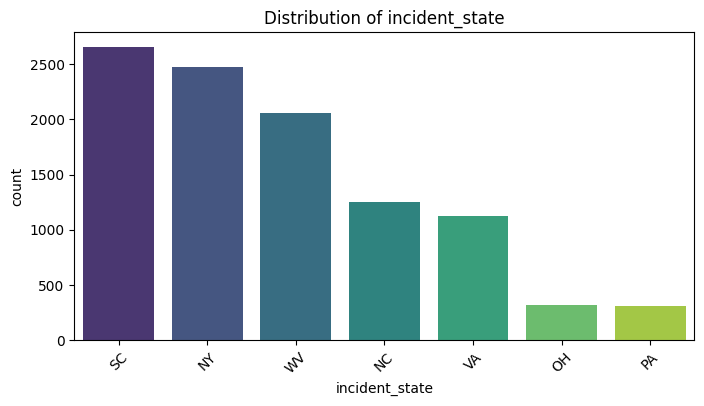

<ipython-input-191-ac7d0284b9eb>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="viridis")


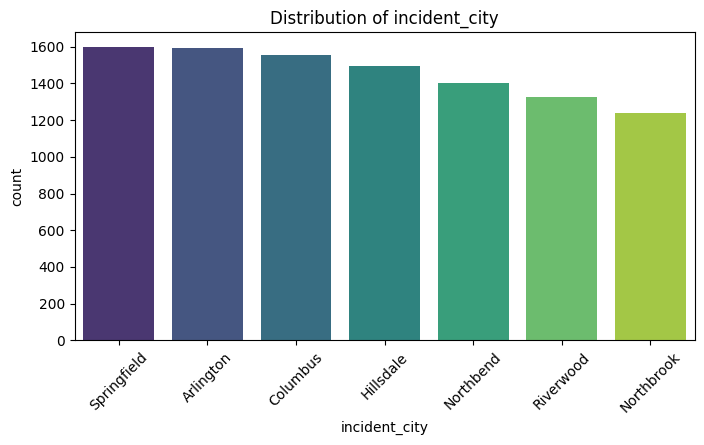

<ipython-input-191-ac7d0284b9eb>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="viridis")


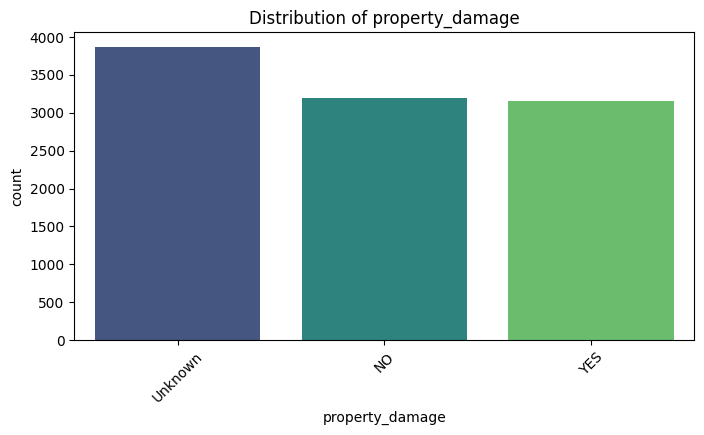

<ipython-input-191-ac7d0284b9eb>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="viridis")


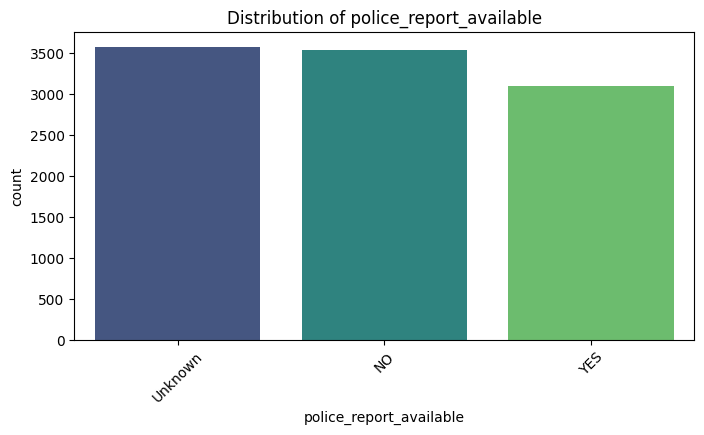

In [191]:
# Incident-Related Variables
incident_cols = ['incident_type', 'collision_type', 'authorities_contacted', 'incident_severity',
                 'incident_state', 'incident_city', 'property_damage', 'police_report_available']

for col in incident_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=new_df[col], order=new_df[col].value_counts().index, palette="viridis")
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()


<ipython-input-192-81bdcc1ffeb1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index[:10], palette="magma")  # Show only top 10


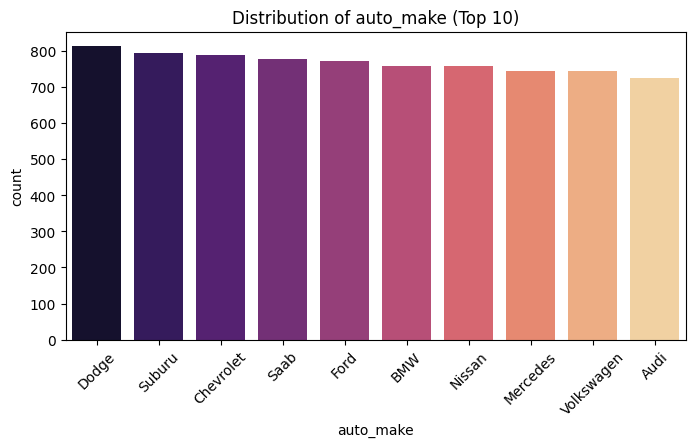

<ipython-input-192-81bdcc1ffeb1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index[:10], palette="magma")  # Show only top 10


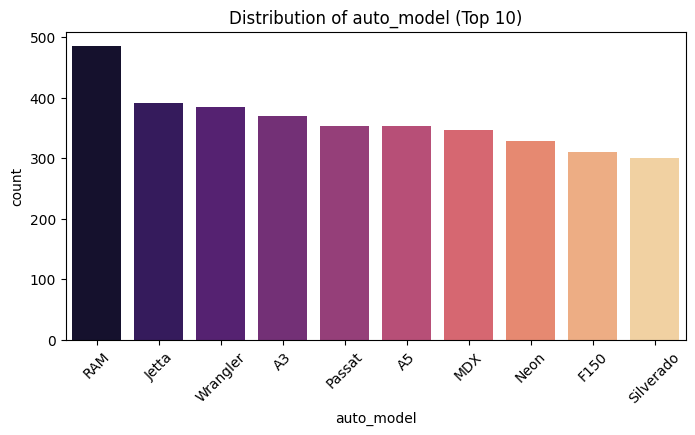

<ipython-input-192-81bdcc1ffeb1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_df[col], order=new_df[col].value_counts().index[:10], palette="magma")  # Show only top 10


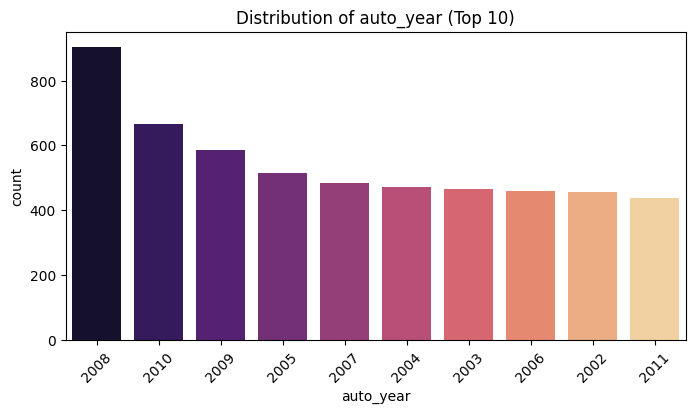

In [192]:
#Vehicle-Related Variables
vehicle_cols = ['auto_make', 'auto_model', 'auto_year']

for col in vehicle_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=new_df[col], order=new_df[col].value_counts().index[:10], palette="magma")  # Show only top 10
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col} (Top 10)")
    plt.show()


**Bivariate Analysis (Finding Relationships Between Variables)**

Since our end goal is Customer Lifetime Value (CLV) prediction, bivariate analysis should focus on how different variables impact CLV and other important business metrics like claims, customer tenure, and policy premiums

In [198]:
#encoding for correaltion between numeric and categoric

from sklearn.preprocessing import LabelEncoder
encoded_df = new_df.copy()
for col in encoded_df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(encoded_df[col])

In [199]:
encoded_df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,5,37,939011,489,1,1,500,1145.28,0.0,360963,...,1,2,96200.0,3000.0,500,58870,10,1,1997,0
1,462,58,902576,504,0,2,1000,1156.80,0.0,432568,...,5,1,31200.0,3830.0,7370,32130,10,3,2006,0
2,198,51,575784,676,2,0,2000,751.02,0.0,712296,...,3,1,14500.0,0.0,0,5690,3,25,1996,0
3,384,47,102488,333,2,0,500,1137.34,1000000.0,402197,...,1,0,7500.0,0.0,0,420,10,3,1990,0
4,100,27,1129102,841,0,0,2000,1082.70,4000000.0,577005,...,1,2,16500.0,5400.0,4300,8270,12,18,1998,0


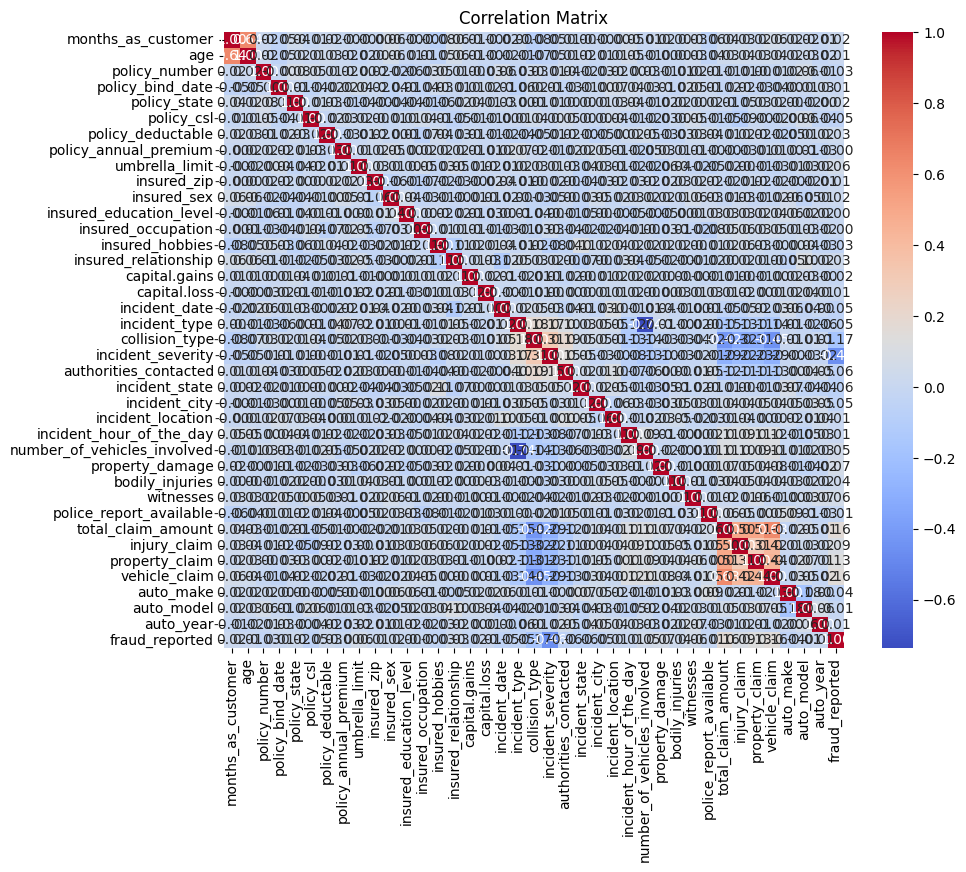

In [200]:
#Correlation Heatmap (Overall View)
plt.figure(figsize=(10,8))
sns.heatmap(encoded_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

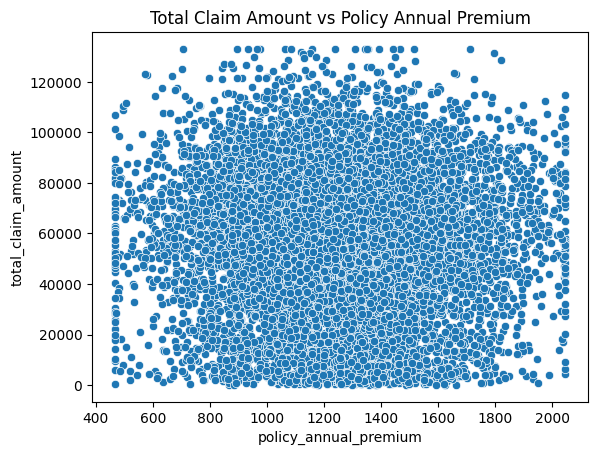

In [201]:
#Total Claim Amount vs. Policy Annual Premium
sns.scatterplot(x=encoded_df['policy_annual_premium'], y=encoded_df['total_claim_amount'])
plt.title("Total Claim Amount vs Policy Annual Premium")
plt.show()
#Insight:Does a higher policy premium lead to higher claim amounts?

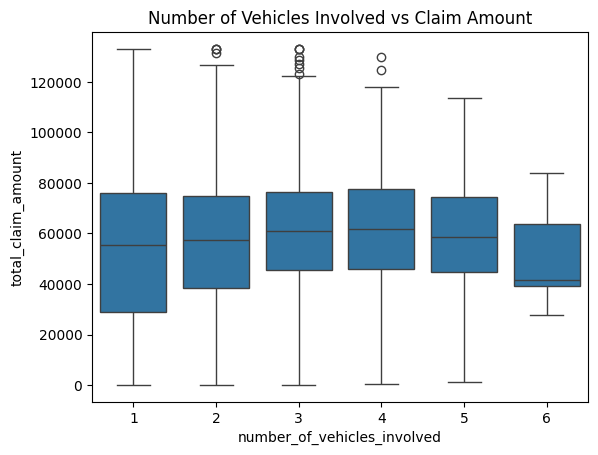

In [202]:
#Number of Vehicles vs. Claim Amount
sns.boxplot(x=encoded_df['number_of_vehicles_involved'], y=encoded_df['total_claim_amount'])
plt.title("Number of Vehicles Involved vs Claim Amount")
plt.show()
# Insight:Do multi-vehicle accidents have higher claims?

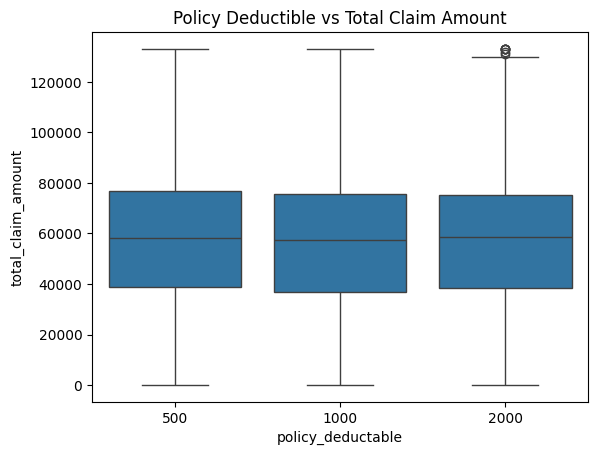

In [203]:
#Policy Deductible vs. Claim Amount
sns.boxplot(x=encoded_df['policy_deductable'], y=encoded_df['total_claim_amount'])
plt.title("Policy Deductible vs Total Claim Amount")
plt.show()
#Insight:Higher deductibles might result in lower claim amounts.

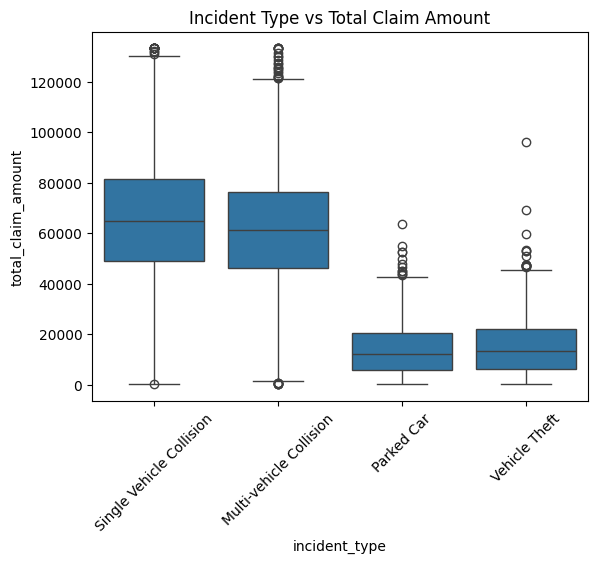

In [204]:
# Incident Type vs. Claim Amount
sns.boxplot(x=new_df['incident_type'], y=new_df['total_claim_amount'])
plt.xticks(rotation=45)
plt.title("Incident Type vs Total Claim Amount")
plt.show()
#Insight:Certain incident types may lead to higher claims.

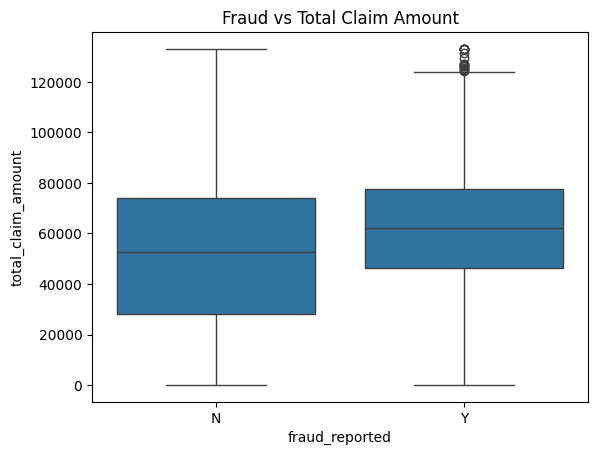

In [205]:
#Fraud Reported vs. Claim Amount
sns.boxplot(x=new_df['fraud_reported'], y=new_df['total_claim_amount'])
plt.title("Fraud vs Total Claim Amount")
plt.show()
#Insight:Fraudulent claims might have higher amounts.

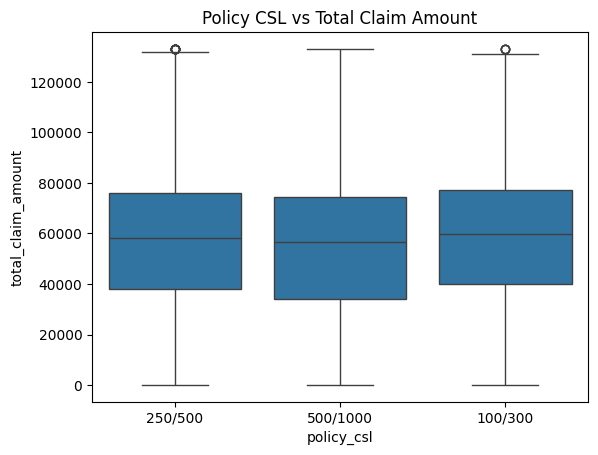

In [206]:
#Policy CSL vs. Claim Amount
sns.boxplot(x=new_df['policy_csl'], y=new_df['total_claim_amount'])
plt.title("Policy CSL vs Total Claim Amount")
plt.show()
#Insight:Does higher CSL (combined single limit) lead to higher claims?

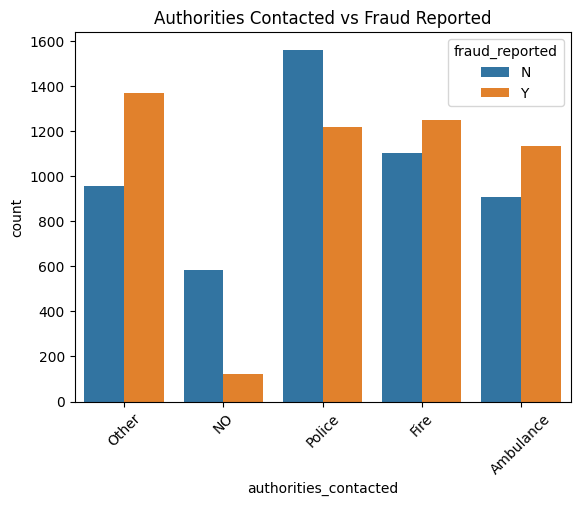

In [207]:
#Fraud Reported vs. Authorities Contacted
sns.countplot(x=new_df['authorities_contacted'], hue=new_df['fraud_reported'])
plt.title("Authorities Contacted vs Fraud Reported")
plt.xticks(rotation=45)
plt.show()
#Insight:Are fraud cases more likely to be reported to the police?

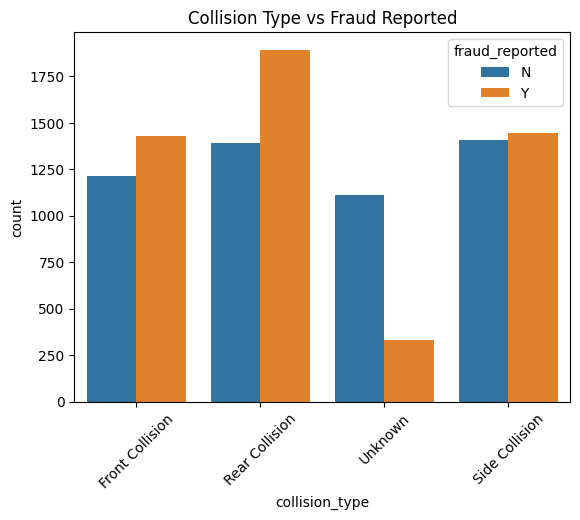

In [208]:
#Collision Type vs. Fraud Reported
sns.countplot(x=new_df['collision_type'], hue=new_df['fraud_reported'])
plt.title("Collision Type vs Fraud Reported")
plt.xticks(rotation=45)
plt.show()
#Insight:Certain collision types may have higher fraud cases.

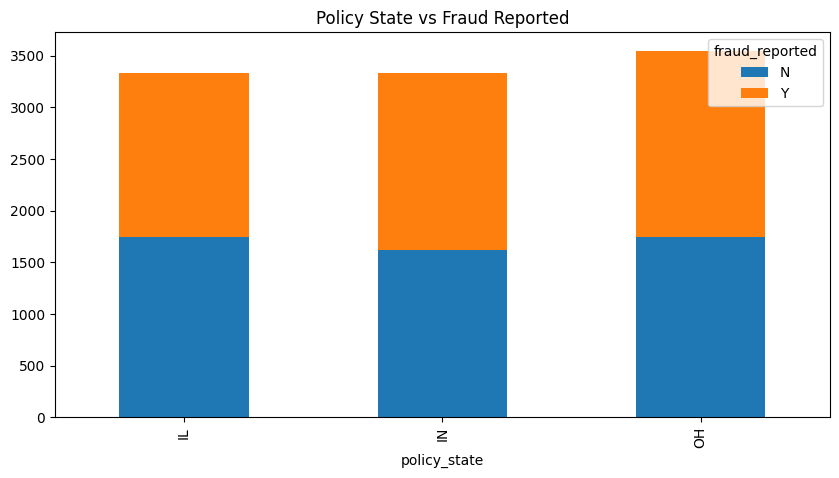

In [209]:
#Policy State vs. Fraud Reported
fraud_counts = new_df.groupby(['policy_state', 'fraud_reported']).size().unstack()
fraud_counts.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("Policy State vs Fraud Reported")
plt.show()
#Insight:Does fraud occur more in certain states?

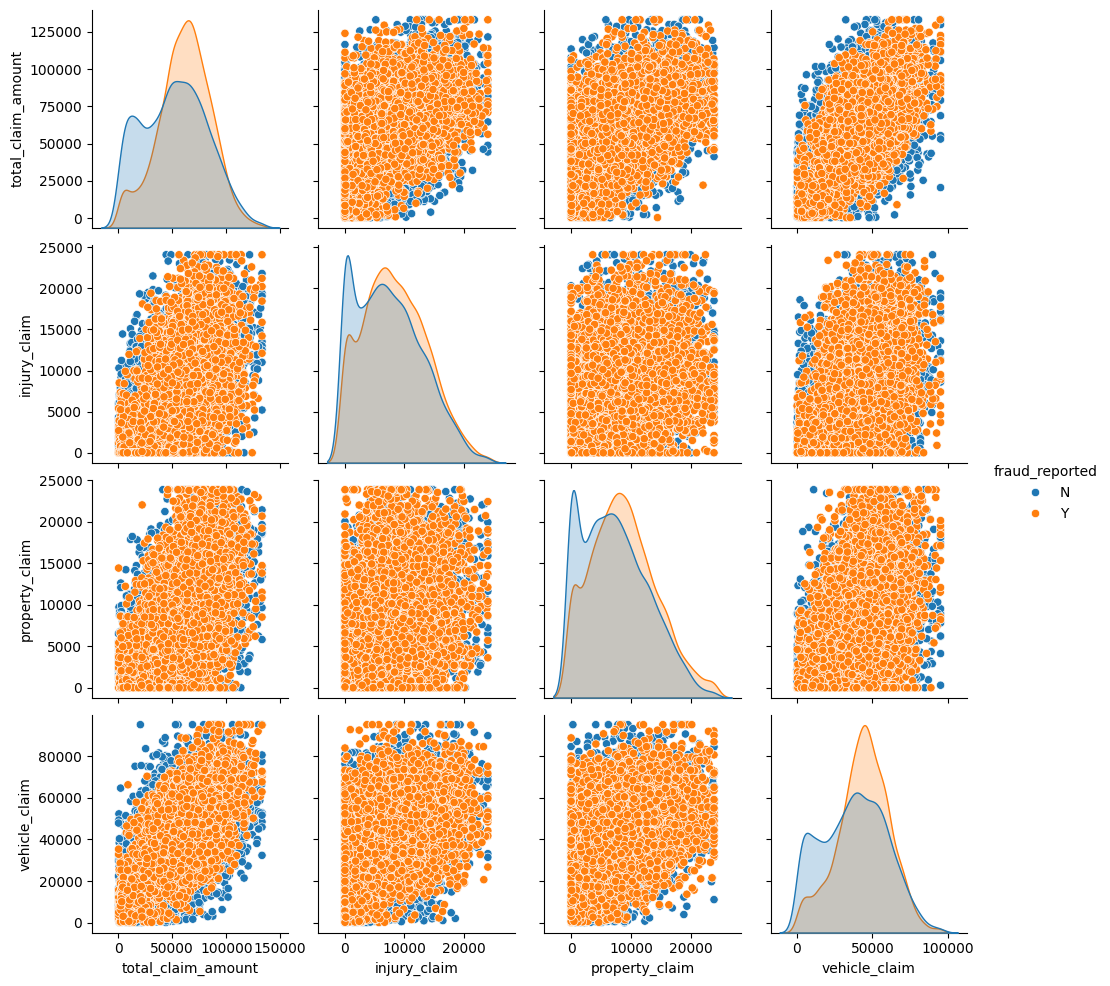

In [210]:
#Pairplots for Strong Correlations
#Visualize relationships between highly correlated numerical features.
sns.pairplot(new_df, vars=['total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim'], hue='fraud_reported')
plt.show()
#Helps spot patterns in high-value claims & fraud.

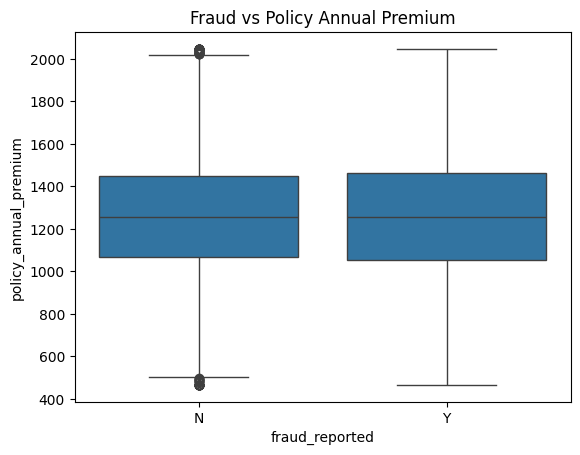

In [211]:
#Fraud vs. High-Premium Policies
#Are fraud cases linked to higher policy annual premiums?
sns.boxplot(x=new_df['fraud_reported'], y=new_df['policy_annual_premium'])
plt.title("Fraud vs Policy Annual Premium")
plt.show()
#Helps check if fraud happens more in high-premium policies.

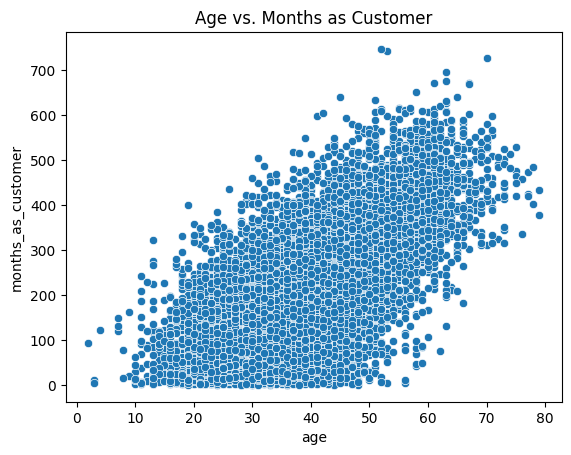

In [212]:
#Age vs. Months as Customer
#If older customers tend to stay longer, it could indicate customer retention trends,
#which are relevant for CLV.
sns.scatterplot(x=new_df['age'], y=new_df['months_as_customer'])
plt.title("Age vs. Months as Customer")
plt.show()
#Correlation Interpretation:Strong positive correlation? → Older customers stay longer.
#Weak correlation? → No strong age-retention relationship.

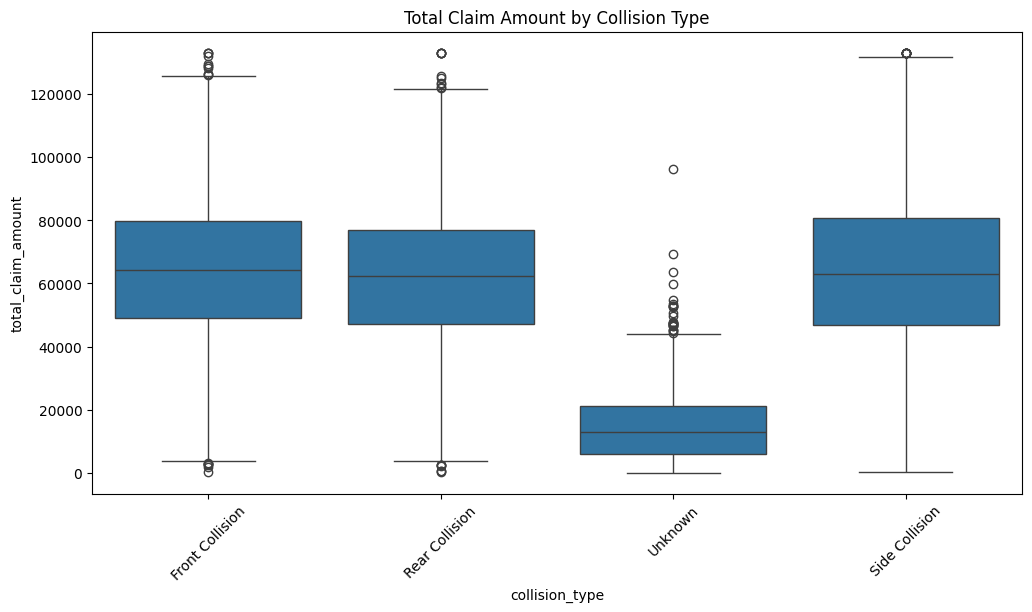

In [213]:
#Collision Type vs. Total Claim Amount, Injury Claim, Property Claim, Vehicle Claim
#Different collision types may lead to higher claims, affecting fraud detection & policy adjustments.
plt.figure(figsize=(12,6))
sns.boxplot(x=new_df['collision_type'], y=new_df['total_claim_amount'])
plt.title("Total Claim Amount by Collision Type")
plt.xticks(rotation=45)
plt.show()

**feature selection before clv**

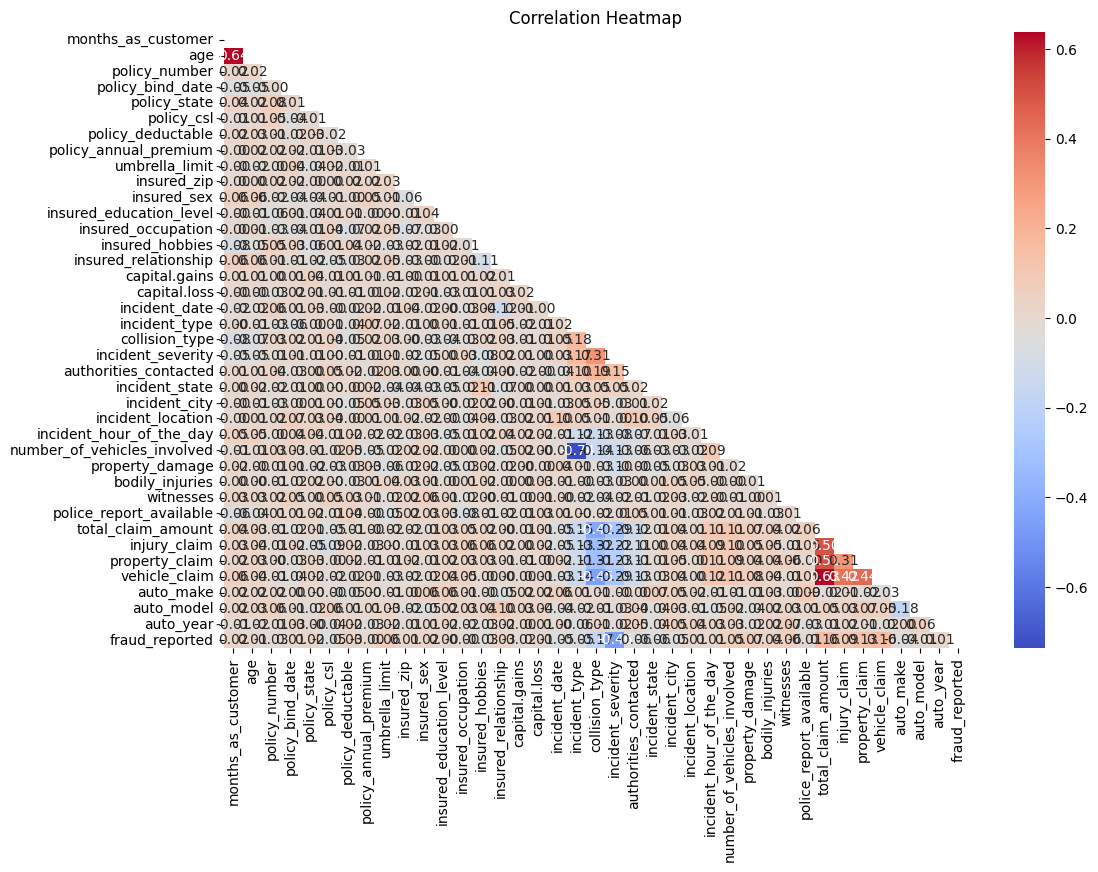

In [214]:
#To remove irrelevant variables before modeling CLV.
#Correlation Check (For Multicollinearity)
corr_matrix = encoded_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

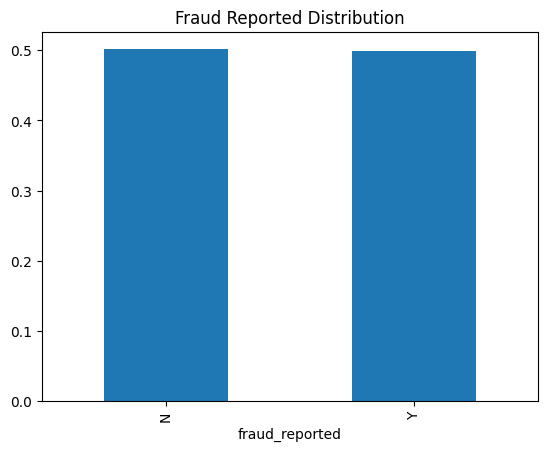

In [215]:
new_df['fraud_reported'].value_counts(normalize=True).plot(kind='bar')
plt.title("Fraud Reported Distribution")
plt.show()

In [216]:
#from sklearn.preprocessing import StandardScaler

# Identify only numerical columns
#num_features = ['months_as_customer', 'policy_annual_premium', 'total_claim_amount',
#                'injury_claim', 'property_claim', 'vehicle_claim', 'number_of_vehicles_involved']

# Initialize and apply StandardScaler
#scaler = StandardScaler()
#encoded_df[num_features] = scaler.fit_transform(encoded_df[num_features])

# Verify the transformation
#encoded_df.head()


**historic clv**

In [217]:
#1-Calculate CLV for Each Customer
#approximate value of how much revenue each customer brings after claims.
encoded_df['CLV'] = (df['policy_annual_premium'] * df['months_as_customer']) - df['total_claim_amount']


In [218]:
#2-Cluster Customers Based on CLV to fing high value low value customer
#Feature Selection for Clustering:We can cluster using:✔ CLV → Customer lifetime value
#✔ months_as_customer → Customer loyalty ✔ policy_annual_premium → Spending capacity ✔ total_claim_amount → Risk factor


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select features
clustering_features = encoded_df[['CLV', 'months_as_customer', 'policy_annual_premium', 'total_claim_amount']]

# Normalize data already done
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
encoded_df['Customer_Segment'] = kmeans.fit_predict(scaled_features)


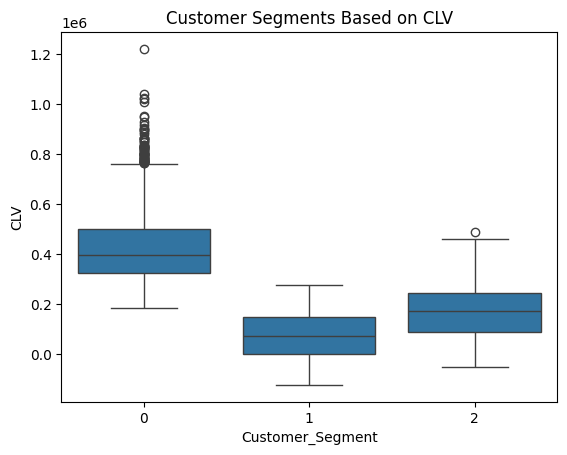

In [219]:
#Visualize Customer Segments
sns.boxplot(x=encoded_df['Customer_Segment'], y=encoded_df['CLV'])
plt.title('Customer Segments Based on CLV')
plt.show()
#This will show how CLV varies across different customer groups.

In [243]:
# Group by Customer Segment and calculate total revenue for each segment
revenue_by_segment = encoded_df.groupby('Customer_Segment')['CLV'].sum().reset_index()

# Rename the columns for clarity
revenue_by_segment.columns = ['Customer_Segment', 'Total_Revenue']

# Display the total revenue for each customer segment
print(revenue_by_segment)


   Customer_Segment  Total_Revenue
0                 0   6.702496e+06
1                 1   1.019261e+07
2                 2   2.857964e+06


In [ ]:
import xgboost as xgb


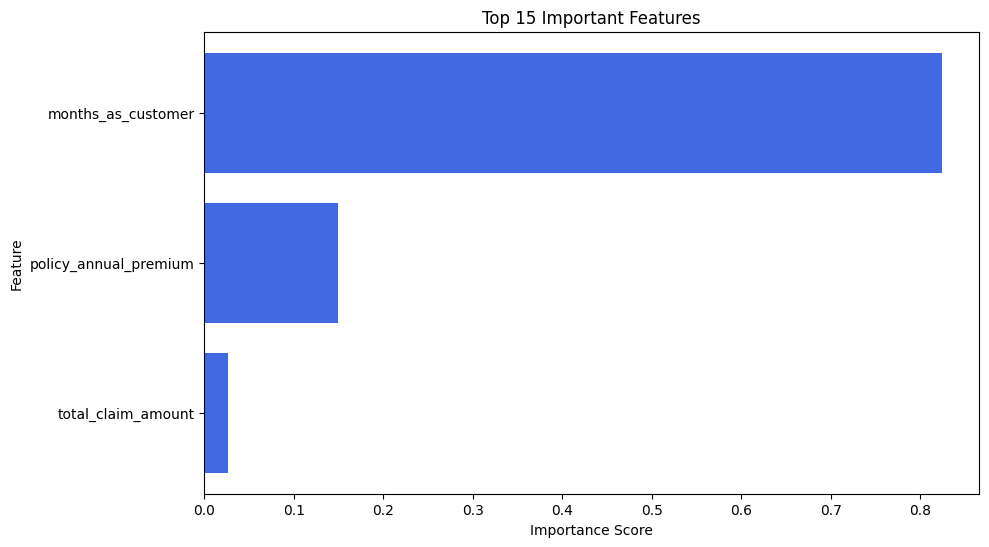

In [142]:
import matplotlib.pyplot as plt
import xgboost as xgb
import numpy as np
import pandas as pd

# Train XGBoost
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)

# Get Feature Importance
importance = xgb_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15], color='royalblue')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")
plt.gca().invert_yaxis()
plt.show()


In [145]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("insurance_claim_updated.csv")
# Define CLV as the target variable
df['CLV'] = (df['policy_annual_premium'] * df['months_as_customer']) - df['total_claim_amount']

# Select only the top 3 important features
features = ['policy_annual_premium', 'months_as_customer', 'total_claim_amount']

# Define Features (X) and Target (y)
X = df[features]
y = df['CLV']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Initialize and train Ridge model
ridge = Ridge(alpha=1.0)  # You can tune alpha for regularization strength
ridge.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = ridge.predict(X_train)
y_pred = ridge.predict(X_test_scaled)
train_r2 = r2_score(y_train, y_train_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("ridge regression")
print(f"Train R² Score: {train_r2:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")








# Assuming 'df' is your dataset
X = df.drop(columns=['CLV'])  # Drop the target variable
y = df['CLV']  # Target variable

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("linear regression")
print(f"Train R² Score: {train_r2:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")










# Define Features (X) and Target (y)
X = df.drop(columns=['CLV'])  # Drop the target column
y = df['CLV']  # Target variable
# Convert categorical features to numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred = xgb_model.predict(X_train)
y_pred = xgb_model.predict(X_test)

# Evaluate Model Performance
train_r2 = r2_score(y_train, y_train_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("XGboost regression")
print(f"Train R² Score: {train_r2:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")








# Prepare X (features) and y (target)
X = df[features]
y = df['CLV']

# Standardizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Evaluate model performance
train_r2 = r2_score(y_train, y_train_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("random forest regression")
print(f"Train R² Score: {train_r2:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


ridge regression
Train R² Score: -79242566.1512
R² Score: 0.9533
Mean Absolute Error (MAE): 25875.95
Root Mean Squared Error (RMSE): 39279.98
linear regression
Train R² Score: 0.9772
R² Score: 0.9710
Mean Absolute Error (MAE): 22435.14
Root Mean Squared Error (RMSE): 30969.33
XGboost regression
Train R² Score: 0.9995
R² Score: 0.9984
Mean Absolute Error (MAE): 4619.69
Root Mean Squared Error (RMSE): 7371.15
random forest regression
Train R² Score: 0.9997
R² Score: 0.9980
Mean Absolute Error (MAE): 4482.49
Root Mean Squared Error (RMSE): 8130.57


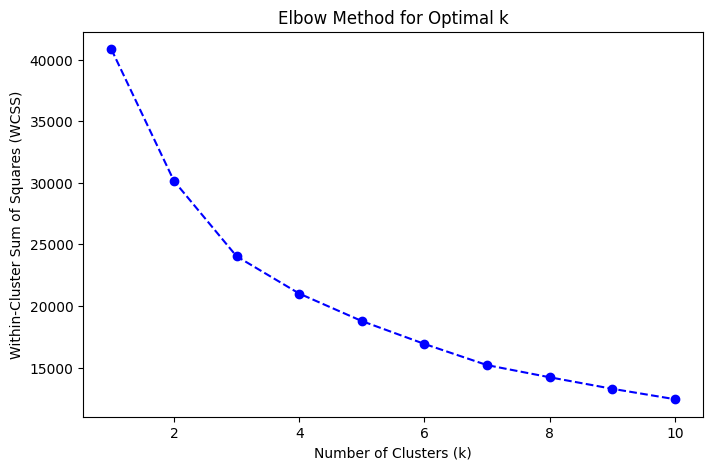

In [114]:
# Elbow Method to Find Optimal k
wcss = []
K_range = range(1, 11)  # Trying k from 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)  # Inertia = WCSS (Sum of squared distances to closest cluster center)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Optimal k")
plt.show()


<ipython-input-147-1ccb536b632c>:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['monthly_revenue'].replace([np.inf, -np.inf], np.nan, inplace=True)
<ipython-input-147-1ccb536b632c>:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

Train R² Score: 0.9851
Test R² Score: 0.9738
Mean Absolute Error (MAE): 0.05
Root Mean Squared Error (RMSE): 0.19
Cross-validation R² Scores: [0.97619842 0.98570343 0.97338119 0.97221849 0.96801496]
Mean CV R²: 0.9751


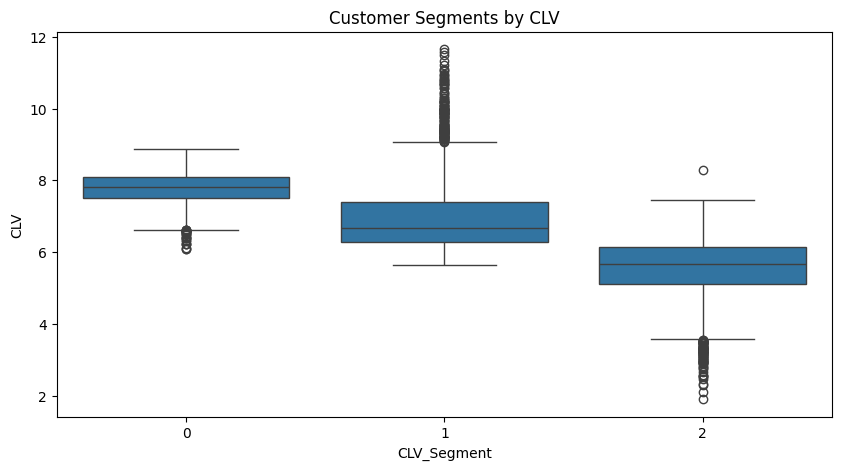

   policy_number       CLV  CLV_Segment
0         939011  9.876633            1
1         902576  6.735110            0
2         575784  4.357034            2
3         102488  5.601812            2
4        1129102  5.175172            2


In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("insurance_claim_updated.csv")

# Step 1: Define Churn (Customer Retention)
df['churn'] = np.where(df['months_as_customer'] < df['months_as_customer'].median(), 1, 0)

# Step 2: Compute CLV using Monthly Revenue & Expected Lifetime
df['monthly_revenue'] = (df['total_claim_amount'] + df['policy_annual_premium']) / df['months_as_customer']
df['monthly_revenue'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['monthly_revenue'].fillna(df['monthly_revenue'].median(), inplace=True)

df['expected_lifetime'] = np.where(df['churn'] == 0, 12, 1)  # If not churned, assume 12 months retention
df['CLV'] = df['monthly_revenue'] * df['expected_lifetime']

# **Log Transformation to Normalize Skewed CLV** (if data is skewed)
df['CLV'] = np.log1p(df['CLV'])

# Step 3: Customer Segmentation using K-Means Clustering
features_for_clustering = ['CLV', 'policy_annual_premium', 'total_claim_amount', 'months_as_customer']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features_for_clustering])



# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['CLV_Segment'] = kmeans.fit_predict(df_scaled)

# Step 4: Future CLV Prediction using XGBoost
# **Adding more predictive features**
features = [
    'policy_annual_premium', 'months_as_customer', 'total_claim_amount',
    'incident_severity', 'policy_deductable', 'number_of_vehicles_involved',
    'witnesses', 'bodily_injuries'
]

# Handling missing values (if any)
categorical_cols = df[features].select_dtypes(include=['object']).columns.tolist()
# **Encode Categorical Variables**
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df[features]
y = df['CLV']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Feature Scaling**
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and Train XGBoost Regressor with **Hyperparameter Tuning**
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=10,   # L1 Regularization (Lasso)
    reg_lambda=10,  # L2 Regularization (Ridge)
    random_state=42
)

# Train with **Early Stopping**
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predictions
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Evaluate Model Performance
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train R² Score: {train_r2:.4f}")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# **Cross-validation to check stability**
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')
print(f"Cross-validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

# Step 5: Visualizing Segments
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['CLV_Segment'], y=df['CLV'])
plt.title("Customer Segments by CLV")
plt.show()

# Display Final DataFrame with CLV and Segments
print(df[['policy_number', 'CLV', 'CLV_Segment']].head())


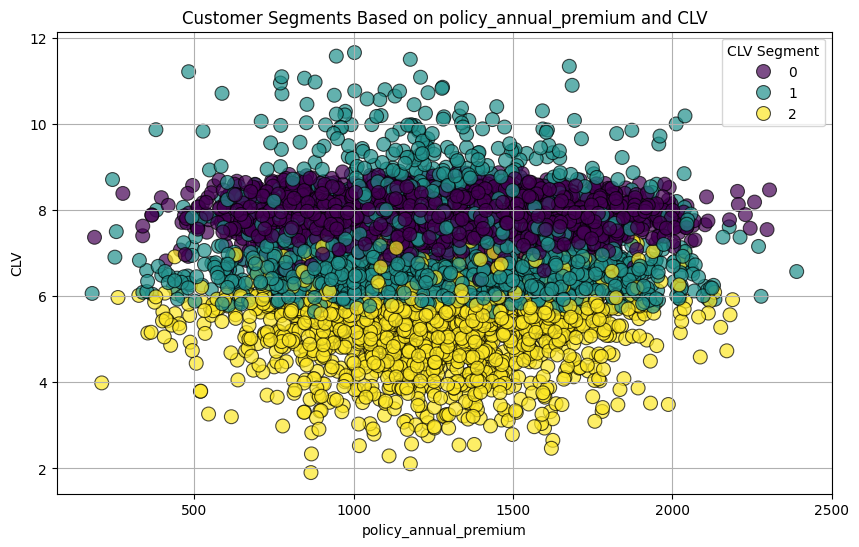

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select two features to plot (you can change them as needed)
x_feature = "policy_annual_premium"
y_feature = "CLV"

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[x_feature], y=df[y_feature], hue=df["CLV_Segment"], palette="viridis", s=100, alpha=0.7, edgecolors="k")

# Titles and labels
plt.title(f"Customer Segments Based on {x_feature} and {y_feature}")
plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.legend(title="CLV Segment")
plt.grid(True)
plt.show()


   CLV Segment  Total CLV Contribution
0            0            33492.796930
1            1            23260.419330
2            2            14343.490074


<ipython-input-149-a3f5ebf2b90c>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_clv_totals['CLV Segment'], y=cluster_clv_totals['Total CLV Contribution'], palette='viridis')


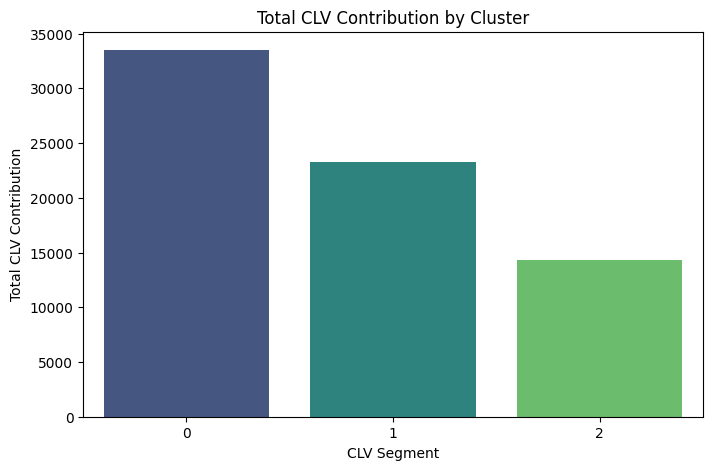

In [149]:
# Calculate total CLV for each cluster
cluster_clv_totals = df.groupby('CLV_Segment')['CLV'].sum().reset_index()

# Rename columns for clarity
cluster_clv_totals.columns = ['CLV Segment', 'Total CLV Contribution']

# Display total CLV contribution per cluster
print(cluster_clv_totals)

# Visualizing Total CLV Contribution
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_clv_totals['CLV Segment'], y=cluster_clv_totals['Total CLV Contribution'], palette='viridis')
plt.title("Total CLV Contribution by Cluster")
plt.xlabel("CLV Segment")
plt.ylabel("Total CLV Contribution")
plt.show()
